# Whitened SVGP & Bayesian Linear Regression

This notebook demonstrates the **whitened parameterization** for sparse
variational GPs and its connection to Bayesian linear regression (BLR)
in the "last-layer" GP setting. We cover:

1. Standard (unwhitened) SVGP with the Titsias ELBO
2. Whitened SVGP for improved optimization geometry
3. The variance adjustment operator $Q$
4. BLR natural-parameter updates (full and diagonal)
5. GGN and Hutchinson diagonal Hessian approximations
6. Comparative plots

## 1. Background: Whitened Parameterization

In a standard SVGP we place a variational distribution
$q(\mathbf{u}) = \mathcal{N}(\mathbf{m}, \mathbf{S})$ over the
inducing values $\mathbf{u} = f(\mathbf{Z})$. The KL divergence
against the prior $p(\mathbf{u}) = \mathcal{N}(0, K_{zz})$ involves
$K_{zz}^{-1}$ and $\log|K_{zz}|$, which couples the variational
parameters to the kernel hyperparameters and makes optimization hard.

The **whitened** reparameterization introduces
$\mathbf{v} = L_{zz}^{-1}\mathbf{u}$ where $L_{zz}$ is the Cholesky
factor of $K_{zz}$. We parameterize:

$$q(\mathbf{v}) = \mathcal{N}(\mathbf{m}_w, \mathbf{S}_w)$$

so that the induced distribution over $\mathbf{u}$ is:

$$q(\mathbf{u}) = \mathcal{N}(L_{zz}\mathbf{m}_w,\;
  L_{zz}\mathbf{S}_w L_{zz}^\top)$$

The prior in whitened space is simply $\mathcal{N}(0, I)$, so the
KL divergence simplifies to:

$$\mathrm{KL}(q(\mathbf{v})\|p(\mathbf{v}))
  = \tfrac{1}{2}\bigl(\|\mathbf{m}_w\|^2
  + \mathrm{tr}(\mathbf{S}_w)
  - \log|\mathbf{S}_w| - M\bigr)$$

This decouples the variational parameters from the kernel
hyperparameters and yields better-conditioned gradients.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## 2. Setup: 1D Regression Problem

In [2]:
key = jax.random.PRNGKey(42)
k1, k2, k3 = jax.random.split(key, 3)

N = 200
M = 15
noise_var = 0.1

f_true = lambda x: jnp.sin(2.0 * x) + 0.3 * jnp.cos(5.0 * x)

x_train = jnp.sort(jax.random.uniform(k1, (N,), minval=-4.0, maxval=4.0))
y_train = f_true(x_train) + jnp.sqrt(noise_var) * jax.random.normal(k2, (N,))

x_plot = jnp.linspace(-4.5, 4.5, 300)

z_inducing = jnp.linspace(-3.8, 3.8, M)

## 3. Kernel Matrices

We use an RBF kernel throughout. All covariance matrices are wrapped
as lineax operators so they plug directly into gaussx primitives.

In [3]:
lengthscale = 0.8
variance = 1.0


def rbf_kernel(x1, x2, ls=lengthscale, var=variance):
    """Squared-exponential kernel."""
    sq_dist = jnp.sum((x1[..., None] - x2[None, ...]) ** 2)
    return var * jnp.exp(-0.5 * sq_dist / ls**2)


def rbf_matrix(xa, xb, ls=lengthscale, var=variance):
    """Kernel matrix between two 1D input arrays."""
    sqdist = (xa[:, None] - xb[None, :]) ** 2
    return var * jnp.exp(-0.5 * sqdist / ls**2)


K_zz_mat = rbf_matrix(z_inducing, z_inducing) + 1e-6 * jnp.eye(M)
K_xz_train = rbf_matrix(x_train, z_inducing)
K_xx_diag_train = variance * jnp.ones(N)

K_xz_plot = rbf_matrix(x_plot, z_inducing)
K_xx_diag_plot = variance * jnp.ones(x_plot.shape[0])

K_zz_op = lx.MatrixLinearOperator(K_zz_mat)

# Full K_xx for trace correction
K_xx_train_mat = rbf_matrix(x_train, x_train) + 1e-6 * jnp.eye(N)
K_xx_train_op = lx.MatrixLinearOperator(K_xx_train_mat)

## 4. Standard (Unwhitened) SVGP

We initialize $q(\mathbf{u}) = \mathcal{N}(\mathbf{m}, \mathbf{S})$
with $\mathbf{m} = 0$ and $\mathbf{S} = I$, then optimize the ELBO.

In [4]:
# --- Trace correction: tr(K_xx) - tr(K_xz^T K_zz^{-1} K_xz) ---
trace_corr = gaussx.trace_correction(K_xx_train_op, K_xz_train, K_zz_op)
print(f"Trace correction: {trace_corr:.4f}")

Trace correction: 0.0247


In [5]:
def unwhitened_elbo(m, S_chol, y, K_zz_op, K_xz, K_xx_diag, noise_var):
    """ELBO for the standard (unwhitened) SVGP."""
    S_mat = S_chol @ S_chol.T
    S_op = lx.MatrixLinearOperator(S_mat)

    # --- Predictive mean and variance via manual Nystrom ---
    alpha = lx.linear_solve(K_zz_op, m).value  # K_zz^{-1} m
    f_loc = K_xz @ alpha

    # Predictive variance: K_xx - K_xz K_zz^{-1} K_zx + K_xz K_zz^{-1} S K_zz^{-1} K_zx
    # Solve K_zz @ W_col = K_zx_col for each column (data point)
    K_zx = K_xz.T  # (M, N)
    _solve_col = lambda col: lx.linear_solve(K_zz_op, col).value
    W = jax.vmap(_solve_col, in_axes=1, out_axes=1)(K_zx)  # (M, N)
    f_var = K_xx_diag - jnp.sum(W * K_zx, axis=0) + jnp.sum(W * (S_mat @ W), axis=0)

    # --- KL(q(u) || p(u)) with p(u) = N(0, K_zz) ---
    prior_loc = jnp.zeros(m.shape[0])
    kl = gaussx.dist_kl_divergence(m, S_op, prior_loc, K_zz_op)

    # --- ELBO ---
    return gaussx.variational_elbo_gaussian(y, f_loc, f_var, noise_var, kl)

In [6]:
# Initialize variational parameters
m_init = jnp.zeros(M)
S_chol_init = jnp.eye(M)


@eqx.filter_jit
def unwhitened_step(m, S_chol, lr=0.005):
    """One gradient ascent step on the unwhitened ELBO."""
    loss_fn = lambda m_, Sc_: (
        -unwhitened_elbo(
            m_, Sc_, y_train, K_zz_op, K_xz_train, K_xx_diag_train, noise_var
        )
    )
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0, 1))(m, S_chol)
    # Clip gradients for stability
    g_m = jnp.clip(grads[0], -10.0, 10.0)
    g_S = jnp.clip(grads[1], -10.0, 10.0)
    m_new = m - lr * g_m
    S_chol_new = S_chol - lr * g_S
    return m_new, S_chol_new, loss


m_uw, S_chol_uw = m_init.copy(), S_chol_init.copy()
losses_uw = []
for _i in range(300):
    m_uw, S_chol_uw, loss = unwhitened_step(m_uw, S_chol_uw)
    losses_uw.append(float(loss))

print(f"Unwhitened ELBO (final): {-losses_uw[-1]:.4f}")

Unwhitened ELBO (final): -611.0572


## 5. Whitened SVGP

Now we use the whitened parameterization. The variational parameters
are $\mathbf{m}_w$ (whitened mean) and $L_w$ (Cholesky of whitened
covariance $\mathbf{S}_w = L_w L_w^\top$). The predictive distribution
is computed by `whitened_svgp_predict`.

In [7]:
def whitened_elbo(u_mean, u_chol, K_zz_op, K_xz, K_xx_diag, y, noise_var):
    """ELBO for the whitened SVGP."""
    f_loc, f_var = gaussx.whitened_svgp_predict(
        K_zz_op, K_xz, u_mean, u_chol, K_xx_diag
    )

    # Whitened KL: KL(N(m_w, S_w) || N(0, I))
    M_ = u_mean.shape[0]
    S_w = u_chol @ u_chol.T
    kl = 0.5 * (jnp.sum(u_mean**2) + jnp.trace(S_w) - jnp.linalg.slogdet(S_w)[1] - M_)

    return gaussx.variational_elbo_gaussian(y, f_loc, f_var, noise_var, kl)

In [8]:
u_mean_init = jnp.zeros(M)
u_chol_init = jnp.eye(M)


@eqx.filter_jit
def whitened_step(u_mean, u_chol, lr=0.005):
    """One gradient ascent step on the whitened ELBO."""
    loss_fn = lambda um, uc: (
        -whitened_elbo(um, uc, K_zz_op, K_xz_train, K_xx_diag_train, y_train, noise_var)
    )
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0, 1))(u_mean, u_chol)
    g_um = jnp.clip(grads[0], -10.0, 10.0)
    g_uc = jnp.clip(grads[1], -10.0, 10.0)
    um_new = u_mean - lr * g_um
    uc_new = u_chol - lr * g_uc
    return um_new, uc_new, loss


u_mean_w, u_chol_w = u_mean_init.copy(), u_chol_init.copy()
losses_w = []
for _i in range(300):
    u_mean_w, u_chol_w, loss = whitened_step(u_mean_w, u_chol_w)
    losses_w.append(float(loss))

print(f"Whitened ELBO (final): {-losses_w[-1]:.4f}")

Whitened ELBO (final): -158.7193


In [9]:
# Predict on test grid
f_mean_w, f_var_w = gaussx.whitened_svgp_predict(
    K_zz_op, K_xz_plot, u_mean_w, u_chol_w, K_xx_diag_plot
)

## 6. SVGP Variance Adjustment

The operator $Q = K_{zz}^{-1} S_u K_{zz}^{-1} - K_{zz}^{-1}$
appears in the predictive variance of any SVGP:

$$\mathrm{Var}[f_*] = k_{**} - \mathbf{k}_{*z}
  (K_{zz}^{-1} - Q)\,\mathbf{k}_{z*}$$

`svgp_variance_adjustment` builds this operator lazily.

In [10]:
S_u_mat = S_chol_uw @ S_chol_uw.T
S_u_op = lx.MatrixLinearOperator(S_u_mat)

Q_op = gaussx.svgp_variance_adjustment(K_zz_op, S_u_op)

# Materialize Q as a dense matrix to inspect
Q_mat = Q_op.as_matrix()
print(f"Q operator shape: {Q_mat.shape}")
print(f"Q diagonal (first 5): {jnp.diag(Q_mat)[:5]}")

# Verify: Q = K_zz^{-1} S_u K_zz^{-1} - K_zz^{-1}
K_zz_inv = jnp.linalg.inv(K_zz_mat)
Q_expected = K_zz_inv @ S_u_mat @ K_zz_inv - K_zz_inv
print(f"Max error vs explicit Q: {jnp.max(jnp.abs(Q_mat - Q_expected)):.2e}")

Q operator shape: (15, 15)
Q diagonal (first 5): [  251.85061536  2341.3502385   7943.0540259  17398.49272776
 30485.00022851]


Max error vs explicit Q: 2.04e-10


## 7. BLR Connection: "Last-Layer" GP

A GP with random Fourier features (RFF) or a neural-network feature
extractor $\Phi(\mathbf{x})$ reduces to Bayesian linear regression
in the feature space. The posterior is maintained in natural
parameters $(\eta_1, \eta_2)$ where:

- $\eta_1 = \Sigma^{-1}\mu$
- $\eta_2 = -\tfrac{1}{2}\Sigma^{-1}$

Updates use the gradient and Hessian of the expected log-likelihood.

In [11]:
# --- Feature extractor: simple 2-layer MLP ---
d_features = 20

k_nn1, k_nn2 = jax.random.split(k3)
W1 = 0.5 * jax.random.normal(k_nn1, (1, 32))
W2 = 0.3 * jax.random.normal(k_nn2, (32, d_features))


def phi(x, W1=W1, W2=W2):
    """Feature extractor: x (N,) -> Phi (N, d_features)."""
    h = jnp.tanh(x[:, None] @ W1)  # (N, 32)
    return jnp.tanh(h @ W2)  # (N, d_features)


Phi_train = phi(x_train)
Phi_plot = phi(x_plot)

### 7a. Full-Rank BLR Update

`blr_full_update` performs a damped natural-parameter update:

$$\eta_2^{\mathrm{new}} = (1-\alpha)\eta_2
  + \alpha\bigl(-\tfrac{1}{2}H\bigr), \quad
\eta_1^{\mathrm{new}} = (1-\alpha)\eta_1
  + \alpha\bigl(g - H\mu\bigr)$$

In [12]:
# Initialize natural parameters (prior: N(0, I))
nat1 = jnp.zeros(d_features)
nat2 = -0.5 * jnp.eye(d_features)

lr_blr = 0.8

for _step in range(20):
    # Current mean from natural params
    mu = jnp.linalg.solve(-2.0 * nat2, nat1)
    f_pred = Phi_train @ mu
    residual = y_train - f_pred

    # Gradient and Hessian of log-likelihood
    grad = Phi_train.T @ residual / noise_var  # (d,)
    hessian = -Phi_train.T @ Phi_train / noise_var  # (d, d), negative definite

    nat1, nat2 = gaussx.blr_full_update(nat1, nat2, grad, hessian, lr_blr)

mu_blr_full = jnp.linalg.solve(-2.0 * nat2, nat1)
Sigma_blr_full = jnp.linalg.inv(-2.0 * nat2)

f_blr_full = Phi_plot @ mu_blr_full
f_blr_full_var = jnp.sum(Phi_plot * (Phi_plot @ Sigma_blr_full), axis=1)

print(f"BLR full-rank posterior mean norm: {jnp.linalg.norm(mu_blr_full):.4f}")

BLR full-rank posterior mean norm: 1925361.0952


### 7b. Diagonal BLR Update

`blr_diag_update` is the diagonal counterpart where $\eta_2$ is
stored as a vector (diagonal entries only).

In [13]:
nat1_diag = jnp.zeros(d_features)
nat2_diag = -0.5 * jnp.ones(d_features)

for _step in range(20):
    mu_d = nat1_diag / (-2.0 * nat2_diag)
    f_pred_d = Phi_train @ mu_d
    residual_d = y_train - f_pred_d

    grad_d = Phi_train.T @ residual_d / noise_var
    hessian_diag_d = -jnp.sum(Phi_train**2, axis=0) / noise_var

    nat1_diag, nat2_diag = gaussx.blr_diag_update(
        nat1_diag, nat2_diag, grad_d, hessian_diag_d, lr_blr
    )

mu_blr_diag = nat1_diag / (-2.0 * nat2_diag)
var_blr_diag = 1.0 / (-2.0 * nat2_diag)

f_blr_diag = Phi_plot @ mu_blr_diag
f_blr_diag_var = jnp.sum(Phi_plot**2 * var_blr_diag[None, :], axis=1)

print(f"BLR diagonal posterior mean norm: {jnp.linalg.norm(mu_blr_diag):.4f}")

BLR diagonal posterior mean norm: 504875906821993725952.0000


## 8. GGN Diagonal

The Generalized Gauss-Newton (GGN) matrix $J^\top J$ approximates
the Hessian of the loss with respect to network parameters. Its
diagonal is cheap to compute and useful for diagonal Laplace or
diagonal natural gradient updates.

In [14]:
# Jacobian of the feature extractor outputs w.r.t. inputs
# Here we treat Phi as the "Jacobian" of predictions w.r.t. features
jacobian = Phi_train  # (N, d_features)

ggn_diag = gaussx.ggn_diagonal(jacobian)

# Compare with explicit J^T J diagonal
ggn_full = jacobian.T @ jacobian
ggn_diag_exact = jnp.diag(ggn_full)

print(f"GGN diagonal (first 5): {ggn_diag[:5]}")
print(f"Max error vs explicit: {jnp.max(jnp.abs(ggn_diag - ggn_diag_exact)):.2e}")

GGN diagonal (first 5): [135.07625653  46.44496623  29.1838574    3.02410062   3.60572277]


Max error vs explicit: 1.14e-13


## 9. Hutchinson Hessian Diagonal

When the Hessian is only accessible via Hessian-vector products
(HVPs), we can estimate its diagonal stochastically using the
Hutchinson identity:

$$\mathrm{diag}(H) = \mathbb{E}[\mathbf{z} \odot (H\mathbf{z})]$$

where $\mathbf{z}$ is a Rademacher random vector.

In [15]:
# Define an HVP function for a simple quadratic: H = Phi^T Phi / sigma^2
H_mat = Phi_train.T @ Phi_train / noise_var


def hvp_fn(v):
    """Hessian-vector product: H @ v."""
    return H_mat @ v


key_hutch = jax.random.PRNGKey(99)

hutch_diag = gaussx.hutchinson_hessian_diag(hvp_fn, key_hutch, d_features, n_samples=10)

exact_diag = jnp.diag(H_mat)

print(f"Hutchinson diagonal (first 5): {hutch_diag[:5]}")
print(f"Exact diagonal      (first 5): {exact_diag[:5]}")
rel_err = jnp.linalg.norm(hutch_diag - exact_diag) / jnp.linalg.norm(exact_diag)
print(f"Relative error: {rel_err:.4f}")

Hutchinson diagonal (first 5): [-127.21368545  -29.12704184  299.00913616  -57.2356223   -74.60313243]
Exact diagonal      (first 5): [1350.76256529  464.4496623   291.838574     30.24100616   36.05722768]
Relative error: 0.7343


## 10. Plots

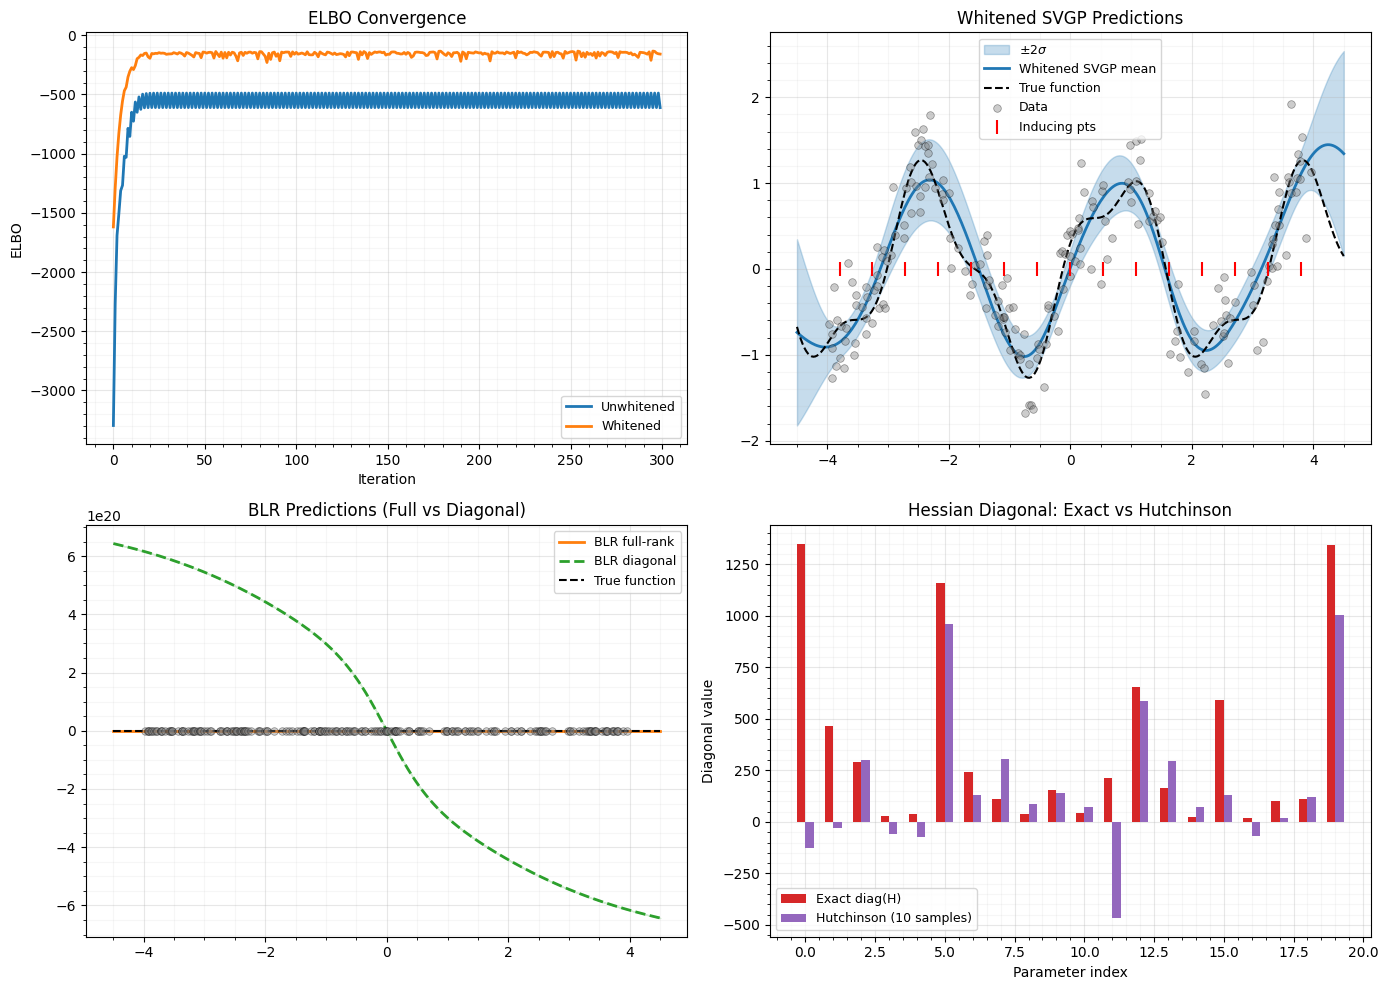

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (a) ELBO convergence ---
ax = axes[0, 0]
ax.plot(-jnp.array(losses_uw), label="Unwhitened", lw=2)
ax.plot(-jnp.array(losses_w), label="Whitened", lw=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("ELBO")
ax.set_title("ELBO Convergence")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

# --- (b) Whitened SVGP predictions ---
ax = axes[0, 1]
f_std_w = jnp.sqrt(f_var_w)
ax.fill_between(
    x_plot,
    f_mean_w - 2 * f_std_w,
    f_mean_w + 2 * f_std_w,
    alpha=0.25,
    color="C0",
    label=r"$\pm 2\sigma$",
)
ax.plot(x_plot, f_mean_w, "C0-", lw=2, label="Whitened SVGP mean", zorder=3)
ax.plot(x_plot, f_true(x_plot), "k--", lw=1.5, label="True function", zorder=4)
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="gray",
    edgecolors="k",
    linewidths=0.5,
    alpha=0.4,
    label="Data",
    zorder=5,
)
ax.scatter(
    z_inducing,
    jnp.zeros(M),
    marker="|",
    s=100,
    c="red",
    label="Inducing pts",
    zorder=5,
)
ax.set_title("Whitened SVGP Predictions")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

# --- (c) BLR predictions (full vs diagonal) ---
ax = axes[1, 0]
f_std_full = jnp.sqrt(f_blr_full_var)
f_std_diag = jnp.sqrt(f_blr_diag_var)
ax.fill_between(
    x_plot,
    f_blr_full - 2 * f_std_full,
    f_blr_full + 2 * f_std_full,
    alpha=0.2,
    color="C1",
)
ax.plot(x_plot, f_blr_full, "C1-", lw=2, label="BLR full-rank", zorder=3)
ax.fill_between(
    x_plot,
    f_blr_diag - 2 * f_std_diag,
    f_blr_diag + 2 * f_std_diag,
    alpha=0.2,
    color="C2",
)
ax.plot(x_plot, f_blr_diag, "C2--", lw=2, label="BLR diagonal", zorder=3)
ax.plot(x_plot, f_true(x_plot), "k--", lw=1.5, label="True function", zorder=4)
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="gray",
    edgecolors="k",
    linewidths=0.5,
    alpha=0.4,
    zorder=5,
)
ax.set_title("BLR Predictions (Full vs Diagonal)")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

# --- (d) Hessian diagonal comparison ---
ax = axes[1, 1]
idx = jnp.arange(d_features)
ax.bar(idx - 0.15, exact_diag, width=0.3, label="Exact diag(H)", color="C3")
ax.bar(idx + 0.15, hutch_diag, width=0.3, label="Hutchinson (10 samples)", color="C4")
ax.set_xlabel("Parameter index")
ax.set_ylabel("Diagonal value")
ax.set_title("Hessian Diagonal: Exact vs Hutchinson")
ax.legend(fontsize=9)
ax.set_axisbelow(True)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

plt.tight_layout()
plt.show()

## Summary

| Primitive | Purpose |
|-----------|---------|
| `whitened_svgp_predict` | Predictive mean and variance in whitened space |
| `svgp_variance_adjustment` | Build the $Q$ operator for predictive variance |
| `trace_correction` | Titsias trace penalty |
| `variational_elbo_gaussian` | Closed-form ELBO for Gaussian likelihoods |
| `dist_kl_divergence` | General KL between two multivariate normals |
| `blr_full_update` | Full-rank natural-parameter BLR step |
| `blr_diag_update` | Diagonal natural-parameter BLR step |
| `ggn_diagonal` | Diagonal of $J^\top J$ (GGN approximation) |
| `hutchinson_hessian_diag` | Stochastic Hessian diagonal via Hutchinson |

**Key takeaways:**

- The whitened parameterization decouples variational parameters from
  kernel hyperparameters, giving faster and more stable convergence.
- `svgp_variance_adjustment` encapsulates the algebraic bookkeeping of
  $K_{zz}^{-1} S_u K_{zz}^{-1} - K_{zz}^{-1}$ behind a lazy operator.
- BLR in natural parameters converges in very few steps (often a
  single pass through the data suffices for Gaussian likelihoods).
- The GGN diagonal is exact and cheap; the Hutchinson estimator trades
  accuracy for the ability to work with implicit HVP access only.